In [ ]:
import numpy as np
import fastf1 as ff1
import pandas as pd

In [ ]:
ff1.Cache.enable_cache('C:\\Users\\jifor\\Python\\F1 Prediction Project\\FF1 Cache')

In [ ]:
season = 2025
schedule = ff1.get_event_schedule(season)
schedule.columns

In [ ]:
session_type = 'R'
rounds = [19, 20, 21, 22, 23, 24]
res_index = 'DriverNumber'
results = pd.DataFrame(columns=rounds)
results

In [ ]:
# Create a dataframe that has the resuls of the 5 races indexed by driver number in increasing order
for round in rounds:
    session = ff1.get_session(season, round, session_type)
    session.load()
    result = pd.Series(session.results.loc[:, 'ClassifiedPosition'])
    result.index = result.index.astype(int)
    result = result.sort_index()
    result = result.replace(['R', 'D'], 20)
    results[round] = result

results

In [ ]:
X = np.array(results.loc[:, rounds[:-1]])
y = np.array(results[rounds[-1]])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [ ]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

In [ ]:
from sklearn.metrics import mean_squared_error
error = mean_squared_error(y_test, predictions)
error

In [ ]:
print(y_test)
print(predictions)

In [1]:
from get_season_results import get_season_results

results = get_season_results(2025)
results

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
1,2,4,1,6,2,4,1,4,10,2,...,2,1,1,2,1,3,3,1,1,1
4,1,2,2,3,4,2,2,1,2,18,...,18,2,7,3,2,1,1,20,4,3
5,20,14,19,18,18,20,18,14,12,14,...,15,8,11,17,18,10,20,20,13,11
6,20,11,8,13,10,11,9,6,7,16,...,3,10,10,11,16,13,8,6,18,17
7,20,13,15,14,17,20,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,11,20,13,7,20,13,13,20,8,15,...,17,16,18,19,19,15,10,13,16,19
12,4,6,6,11,6,6,20,18,20,3,...,16,9,4,5,13,6,2,3,5,15
14,20,20,11,15,11,15,11,20,9,7,...,8,20,15,7,10,20,14,11,7,6
16,8,20,4,4,3,7,6,2,3,5,...,20,4,9,6,3,2,20,4,8,4
18,6,9,20,17,16,16,15,15,NaN,17,...,7,18,17,13,12,14,16,20,17,10


In [3]:
type(results.loc[1,1])

str

In [8]:
x = float('nan')
x = int(x)
x 

ValueError: cannot convert float NaN to integer

#### Testing Model that uses last finish just to get my foot in the door with something

In [1]:
from src.data_loading import get_season_results
from src.features import add_last_finish

In [12]:
results = get_season_results(2025)
results

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

,DriverNumber,RoundNumber,Position
0,1,1,2.0
1,4,1,1.0
2,5,1,20.0
3,6,1,20.0
4,7,1,20.0
...,...,...,...
75,44,4,5.0
76,55,4,20.0
77,63,4,2.0
78,81,4,1.0


In [13]:
data = add_last_finish(results)
data

,DriverNumber,RoundNumber,Position,last_finish
0,1,1,2.0,NaN
1,4,1,1.0,NaN
2,5,1,20.0,NaN
3,6,1,20.0,NaN
4,7,1,20.0,NaN
...,...,...,...,...
75,44,4,5.0,7.0
76,55,4,20.0,14.0
77,63,4,2.0,5.0
78,81,4,1.0,3.0


In [25]:
# Split X and y
import numpy as np
X = np.array(data['last_finish'])
X = X.reshape(-1, 1)
y = np.array(data['Position'])
y = y.reshape(-1, 1)
y

array([[ 2.],
       [ 1.],
       [20.],
       [20.],
       [20.],
       [11.],
       [ 4.],
       [20.],
       [ 8.],
       [ 6.],
       [12.],
       [ 5.],
       [ 7.],
       [20.],
       [13.],
       [10.],
       [20.],
       [ 3.],
       [ 9.],
       [14.],
       [ 4.],
       [ 2.],
       [14.],
       [11.],
       [13.],
       [20.],
       [ 6.],
       [20.],
       [20.],
       [ 9.],
       [16.],
       [ 7.],
       [15.],
       [12.],
       [ 5.],
       [20.],
       [10.],
       [ 3.],
       [ 1.],
       [ 8.],
       [ 1.],
       [ 2.],
       [19.],
       [ 8.],
       [15.],
       [13.],
       [ 6.],
       [11.],
       [ 4.],
       [20.],
       [12.],
       [ 9.],
       [16.],
       [17.],
       [18.],
       [ 7.],
       [14.],
       [ 5.],
       [ 3.],
       [10.],
       [ 6.],
       [ 3.],
       [18.],
       [13.],
       [14.],
       [ 7.],
       [11.],
       [15.],
       [ 4.],
       [17.],
       [ 9.],
      

In [26]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
X

array([[10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [ 2.  ],
       [ 1.  ],
       [20.  ],
       [20.  ],
       [20.  ],
       [11.  ],
       [ 4.  ],
       [20.  ],
       [ 8.  ],
       [ 6.  ],
       [12.  ],
       [ 5.  ],
       [ 7.  ],
       [20.  ],
       [13.  ],
       [10.  ],
       [20.  ],
       [ 3.  ],
       [ 9.  ],
       [14.  ],
       [ 4.  ],
       [ 2.  ],
       [14.  ],
       [11.  ],
       [13.  ],
       [20.  ],
       [ 6.  ],
       [20.  ],
       [20.  ],
       [ 9.  ],
       [16.  ],
       [ 7.  ],
       [15.  ],
       [12.  ],
       [ 5.  ],
       [20.  ],
       [10.  ],
       [ 3.  ],
       [ 1.  ],
       [ 8.  ],
       [ 1.  ],
       [ 2.  ],
       [

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
X_train

array([[ 5.  ],
       [10.85],
       [ 6.  ],
       [10.85],
       [ 2.  ],
       [ 8.  ],
       [11.  ],
       [20.  ],
       [16.  ],
       [10.  ],
       [13.  ],
       [20.  ],
       [10.85],
       [13.  ],
       [ 4.  ],
       [ 8.  ],
       [11.  ],
       [10.85],
       [ 4.  ],
       [16.  ],
       [ 7.  ],
       [12.  ],
       [10.  ],
       [ 7.  ],
       [20.  ],
       [20.  ],
       [14.  ],
       [13.  ],
       [ 3.  ],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [ 6.  ],
       [ 4.  ],
       [10.85],
       [20.  ],
       [10.85],
       [ 9.  ],
       [12.  ],
       [12.  ],
       [ 5.  ],
       [10.85],
       [ 3.  ],
       [ 1.  ],
       [ 9.  ],
       [10.85],
       [10.85],
       [19.  ],
       [10.85],
       [20.  ],
       [18.  ],
       [10.85]])

In [29]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

/Users/jason/Desktop/Python/F1 Prediction Project/F1-Prediction-Project/venv/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array([11.51299504, 11.46515209, 17.741     , 16.04166667,  7.58066667,
       11.87349562, 11.51299504,  4.81466667,  8.94133333,  3.25466667,
        4.81466667, 11.87349562, 11.87349562, 17.741     , 11.51299504,
       14.96365057, 10.11733333, 11.51299504, 14.809     , 11.87349562,
       11.87349562,  2.08928571, 11.51299504,  7.87572222, 16.04166667,
       13.85      ,  3.25466667])

In [30]:
from sklearn.metrics import mean_squared_error
error = mean_squared_error(y_test, predictions)
error

26.9337834957332

Terrible error but who cares because I got it to work

Now, I'll do the same thing but using all of 2025 season

In [1]:
from src.data_loading import get_season_results
from src.features import add_last_finish

results = get_season_results(2025)
results

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

,DriverNumber,RoundNumber,Position
0,1,1,2.0
1,4,1,1.0
2,5,1,20.0
3,6,1,20.0
4,7,1,20.0
...,...,...,...
474,44,24,8.0
475,55,24,13.0
476,63,24,5.0
477,81,24,2.0


In [2]:
data = add_last_finish(results)
data

,DriverNumber,RoundNumber,Position,last_finish
0,1,1,2.0,NaN
1,4,1,1.0,NaN
2,5,1,20.0,NaN
3,6,1,20.0,NaN
4,7,1,20.0,NaN
...,...,...,...,...
474,44,24,8.0,12.0
475,55,24,13.0,3.0
476,63,24,5.0,6.0
477,81,24,2.0,2.0


In [3]:
# Split X and y
import numpy as np
X = np.array(data['last_finish'])
X = X.reshape(-1, 1)
y = np.array(data['Position'])
y = y.reshape(-1, 1)
y

array([[ 2.],
       [ 1.],
       [20.],
       [20.],
       [20.],
       [11.],
       [ 4.],
       [20.],
       [ 8.],
       [ 6.],
       [12.],
       [ 5.],
       [ 7.],
       [20.],
       [13.],
       [10.],
       [20.],
       [ 3.],
       [ 9.],
       [14.],
       [ 4.],
       [ 2.],
       [14.],
       [11.],
       [13.],
       [20.],
       [ 6.],
       [20.],
       [20.],
       [ 9.],
       [16.],
       [ 7.],
       [15.],
       [12.],
       [ 5.],
       [20.],
       [10.],
       [ 3.],
       [ 1.],
       [ 8.],
       [ 1.],
       [ 2.],
       [19.],
       [ 8.],
       [15.],
       [13.],
       [ 6.],
       [11.],
       [ 4.],
       [20.],
       [12.],
       [ 9.],
       [16.],
       [17.],
       [18.],
       [ 7.],
       [14.],
       [ 5.],
       [ 3.],
       [10.],
       [ 6.],
       [ 3.],
       [18.],
       [13.],
       [14.],
       [ 7.],
       [11.],
       [15.],
       [ 4.],
       [17.],
       [ 9.],
      

In [4]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
X

array([[10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [ 2.        ],
       [ 1.        ],
       [20.        ],
       [20.        ],
       [20.        ],
       [11.        ],
       [ 4.        ],
       [20.        ],
       [ 8.        ],
       [ 6.        ],
       [12.        ],
       [ 5.        ],
       [ 7.        ],
       [20.        ],
       [13.        ],
       [10.        ],
       [20.        ],
       [ 3.        ],
       [ 9.        ],
       [14.        ],
       [ 4.        ],
       [ 2.        ],
       [14.        ],
       [11.        ],
       [13.        ],
       [20

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
X_train

array([[ 4.        ],
       [12.        ],
       [ 6.        ],
       [10.        ],
       [20.        ],
       [ 3.        ],
       [12.        ],
       [ 9.        ],
       [20.        ],
       [ 6.        ],
       [11.        ],
       [18.        ],
       [16.        ],
       [11.        ],
       [17.        ],
       [14.        ],
       [20.        ],
       [20.        ],
       [ 5.        ],
       [15.        ],
       [10.61135371],
       [15.        ],
       [ 5.        ],
       [16.        ],
       [ 4.        ],
       [ 1.        ],
       [17.        ],
       [ 1.        ],
       [ 7.        ],
       [20.        ],
       [14.        ],
       [ 4.        ],
       [10.61135371],
       [ 5.        ],
       [ 9.        ],
       [13.        ],
       [13.        ],
       [19.        ],
       [ 2.        ],
       [ 3.        ],
       [ 9.        ],
       [20.        ],
       [10.61135371],
       [17.        ],
       [15.        ],
       [ 9

In [6]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

/Users/jason/Desktop/Python/F1 Prediction Project/F1-Prediction-Project/venv/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array([11.03524139, 14.241754  ,  5.60269535, 12.69622112,  4.83870917,
       11.03524139, 13.24697744, 13.80060861,  5.60269535, 11.03524139,
       14.241754  , 12.69622112, 11.71488377, 11.53931535, 12.47717521,
       13.00353802, 13.80060861, 11.53931535, 13.00353802, 11.03524139,
       16.50652381,  8.62436124, 12.69622112, 12.59277771, 13.80060861,
       12.59277771, 11.03524139,  9.18071325, 16.50652381, 13.80060861,
       11.03524139,  4.16747256,  5.60269535,  9.18071325,  8.62736415,
       12.69622112, 12.47717521, 13.91585139,  4.16747256, 12.95176182,
       11.71488377, 11.03524139,  4.16747256, 13.80060861,  6.77473906,
       12.95176182, 11.71488377, 11.53931535, 12.59277771,  8.62736415,
       11.03524139,  8.62736415, 12.95176182,  4.83870917,  6.77473906,
        8.62736415, 11.03524139, 12.95176182, 11.53931535,  8.62736415,
       11.03524139, 12.69622112, 12.69622112, 11.53931535, 12.95176182,
       11.03524139, 14.241754  , 12.69622112, 12.69622112, 11.03

In [7]:
from sklearn.metrics import mean_squared_error
error = mean_squared_error(y_test, predictions)
error

27.31657660112008

Even worse but who cares it works

Now Testing model with rolling average of last 3 races and 3 race consistency

In [1]:
from src.data_loading import get_season_results
from src.features import (
    add_rolling_3_avg,
    add_3_race_consistency
)

results = get_season_results(2025)
results

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

,DriverNumber,RoundNumber,Position
0,1,1,2.0
1,4,1,1.0
2,5,1,20.0
3,6,1,20.0
4,7,1,20.0
...,...,...,...
474,44,24,8.0
475,55,24,13.0
476,63,24,5.0
477,81,24,2.0


In [2]:
data2 = add_rolling_3_avg(results)
data2 = add_3_race_consistency(data2)
data2

,DriverNumber,RoundNumber,Position,RollingAverage3,RollingStd3
0,1,1,2.0,2.000000,0.000000
20,1,2,4.0,2.000000,0.000000
40,1,3,1.0,3.000000,1.414214
60,1,4,6.0,2.333333,1.527525
80,1,5,2.0,3.666667,2.516611
...,...,...,...,...,...
398,87,20,4.0,10.000000,1.732051
418,87,21,6.0,7.333333,2.886751
438,87,22,10.0,6.333333,2.516611
458,87,23,20.0,6.666667,3.055050


In [4]:
X = data2[['RollingAverage3', 'RollingStd3']]
y = data2['Position']
X
y

0       2.0
20      4.0
40      1.0
60      6.0
80      2.0
       ... 
398     4.0
418     6.0
438    10.0
458    20.0
478    12.0
Name: Position, Length: 479, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
X_train

,RollingAverage3,RollingStd3
210,9.666667,5.686241
10,12.000000,0.000000
409,13.333333,1.154701
280,1.333333,0.577350
408,10.000000,2.645751
...,...,...
104,15.333333,1.527525
39,14.000000,0.000000
216,5.333333,5.131601
168,12.333333,4.041452


In [6]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

array([ 3.03833333,  1.465     , 12.946     , 18.46      ,  7.9       ,
        1.92157143,  8.44871429, 17.09      , 11.49      , 13.1015    ,
        8.22      , 14.18708333, 15.09      ,  9.3925    , 10.5515    ,
       13.        ,  7.4367619 ,  1.465     , 10.9775    , 15.29333333,
       15.11107143, 13.876     , 11.4475    ,  3.694     ,  8.96380952,
       12.35057143,  3.57009524,  9.966     ,  8.971     ,  7.12285714,
        9.54      , 12.315     ,  6.79416667, 14.7335    , 12.98833333,
        8.29333333, 12.50916667, 14.98666667, 10.96633333, 14.52533333,
       15.88      , 14.71185533,  7.12285714, 11.37      , 12.99883333,
       11.26190476, 13.93      , 17.59      , 16.73233333, 11.93666667,
       12.484     ,  3.57009524,  7.26      , 12.77      ,  3.782     ,
        7.07133333, 12.05966667, 10.235     ,  5.63      ,  4.097     ,
       11.32      , 14.68333333,  4.53883333,  2.806     ,  1.465     ,
        9.64764286,  6.90466667, 10.5515    , 14.71185533,  9.05

In [7]:
from sklearn.metrics import mean_squared_error
error = mean_squared_error(y_test, predictions)
error

34.00702535729462

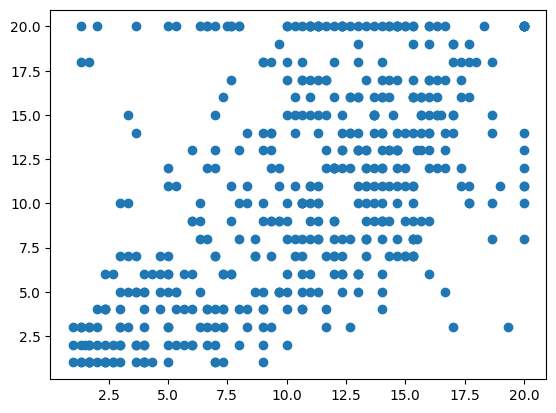

In [9]:
import matplotlib.pyplot as plt

plt.scatter(data2['RollingAverage3'], data2['Position'])

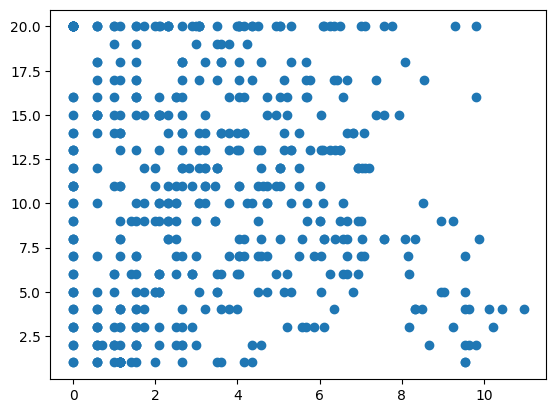

In [10]:
plt.scatter(data2['RollingStd3'], data2['Position'])